This notebook builds the first version of a halo BAO analysis pipeline using fake data

The purpose is to test the workflow:

1. generate a fake halo catalog

2. apply a mass filter

3. compute sample properties

4. compute the 2 point correlation function

5. plot xi(r)

the fake catalog will be replaced by a real N-body simulation halo catalog later

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from Corrfunc.theory.xi import xi

In [21]:
size = 1000.0 #simulation box size
n = 50000 #number of fake halos
m_threshold = 1e14 #solar masses

#Corrfunc
rmin = 20 # Mpc/h, min separation distance i will consider
rmax = 200 
nbins = 80 #dividing range into intervals
rbins = np.linspace(rmin,rmax,nbins+1)

# BAO region
bao_min = 50 #Mpc/h
bao_max = 150

Lit review of 

2 point correlation function: https://ned.ipac.caltech.edu/level5/March12/Coil/Coil2.html for now

Landy-Szalay Estimate function: https://arxiv.org/pdf/1211.6211, use for real observational data process

r value: https://doi.org/10.1051/0004-6361/201220724

Corrfunc: https://github.com/manodeep/Corrfunc

Bao region: https://doi.org/10.1093/mnrasl/slad200




In [22]:
#generate random position and mass 
x = np.random.uniform(0,size,n)
y = np.random.uniform(0,size,n)
z = np.random.uniform(0,size,n)

mass = 10**np.random.uniform(13.25, 14.18, n)
halos = pd.DataFrame({
    "x": x,
    "y": y,
    "z": z,
    "m": mass
})
halos.head()


,x,y,z,mass
0,201.717826,513.538404,966.973844,6.000449e+13
1,813.018512,591.731644,785.785165,1.460275e+14
2,586.503173,112.230439,641.405355,4.225999e+13
3,958.598763,479.255332,229.628871,2.395830e+13
4,173.669239,729.882242,49.724067,2.611038e+13


In [23]:
filtered = halos[halos["m"] > m_threshold].copy()
N_filtered = len(filtered)
V = size**3
rho_N = N_filtered / V
mean_m = filtered["mass"].mean()
print("Number density of halos",rho_N)
print("Mean halo mass",mean_m)
# print("Mass filter threshold",m_threshold)
# print("",)
# print("",)
# filtered.head()


Number density of halos 9.803e-06
Mean halo mass 123989887408011.58


,x,y,z,mass
1,813.018512,591.731644,785.785165,1.460275e+14
9,235.348780,869.539664,396.276674,1.318873e+14
10,918.330977,881.584074,498.508991,1.172436e+14
11,848.758671,627.678752,588.059763,1.310889e+14
24,907.843841,678.872004,727.396169,1.194761e+14


In [24]:
results = xi(boxsize=size,nthreads=4,binfile=rbins,X=filtered["x"].values,Y=filtered["y"].values,Z=filtered["z"].values)
results[:5]

array([(20.  , 22.25, 0.,  0.02011883, 1238, 0.),
       (22.25, 24.5 , 0., -0.04416302, 1420, 0.),
       (24.5 , 26.75, 0.,  0.03857285, 1854, 0.),
       (26.75, 29.  , 0.,  0.03684192, 2190, 0.),
       (29.  , 31.25, 0., -0.00191849, 2462, 0.)],
      dtype=[('rmin', '<f8'), ('rmax', '<f8'), ('ravg', '<f8'), ('xi', '<f8'), ('npairs', '<u8'), ('weightavg', '<f8')])

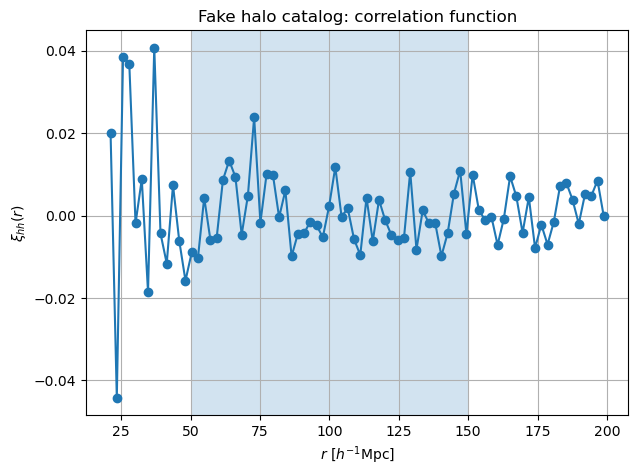

In [28]:
o = 0.5 * (results["rmin"]+results["rmax"]) #origin
xi_values = results["xi"]
plt.figure(figsize=(7, 5))
plt.plot(o, xi_values, marker="o")
plt.axvspan(bao_min, bao_max, alpha=0.2)
plt.xlabel(r"$r\ [h^{-1}\mathrm{Mpc}]$")
plt.ylabel(r"$\xi_{hh}(r)$")
plt.title("Fake halo catalog: correlation function")
plt.grid(True)
plt.show()


Because this catalog is randomly generated, it does not contain real cosmic structure or a real BAO feature. Therefore, xi(r) should be close to zero, which aligns with the result. This notebook is only a pipeline test.  The next step is to replace the fake catalog with a real halo catalog from an N-body simulation.